In [67]:
import os
import pyBigWig
import numpy as np
import pandas as pd
import tqdm.auto as tqdm
from eugene.plot.tracks import plot_tracks

In [68]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_tracks(
    tracks, 
    interval, 
    height=1.5, 
    colors=None,
    sharey=True,
):
  _, axes = plt.subplots(len(tracks), 1, figsize=(20, height * len(tracks)), sharex=True, sharey=sharey)
  if not isinstance(axes, np.ndarray):
    axes = [axes]
  for ax, (title, y) in zip(axes, tracks.items()):
    if colors is not None:
      ax.fill_between(np.linspace(interval["start"], interval["end"], num=len(y)), y, color=colors[title])
    else:
      ax.fill_between(np.linspace(interval["start"], interval["end"], num=len(y)), y)
    ax.set_title(title)
    sns.despine(top=True, right=True, bottom=True)
  ax.set_xlabel(f"{interval['chrom']}:{interval['start']}-{interval['end']}")
  plt.tight_layout()

In [69]:
os.chdir('/cellar/users/aklie/data/datasets/SeqDatasets/HepG2_WGBS')

# Define the regions

In [70]:
chrom = 'chr1'
chromStart = 1
chromEnd = 1000000
interval = dict(chrom=chrom, start=chromStart, end=chromEnd)

# CpG sites coverage

In [71]:
rep1_bw = pyBigWig.open('processed/ENCFF782HWK_HepG2_WGBS_CpG_sites_coverage_rep1.bigWig')
rep2_bw = pyBigWig.open('processed/ENCFF306UZK_HepG2_WGBS_CpG_sites_coverage_rep2.bigWig')

In [72]:
chrom_sizes = list(rep1_bw.chroms().items())

In [73]:
rep1_vals = np.nan_to_num(np.array(rep1_bw.values(chrom, chromStart, chromEnd)))
rep2_vals = np.nan_to_num(np.array(rep2_bw.values(chrom, chromStart, chromEnd)))

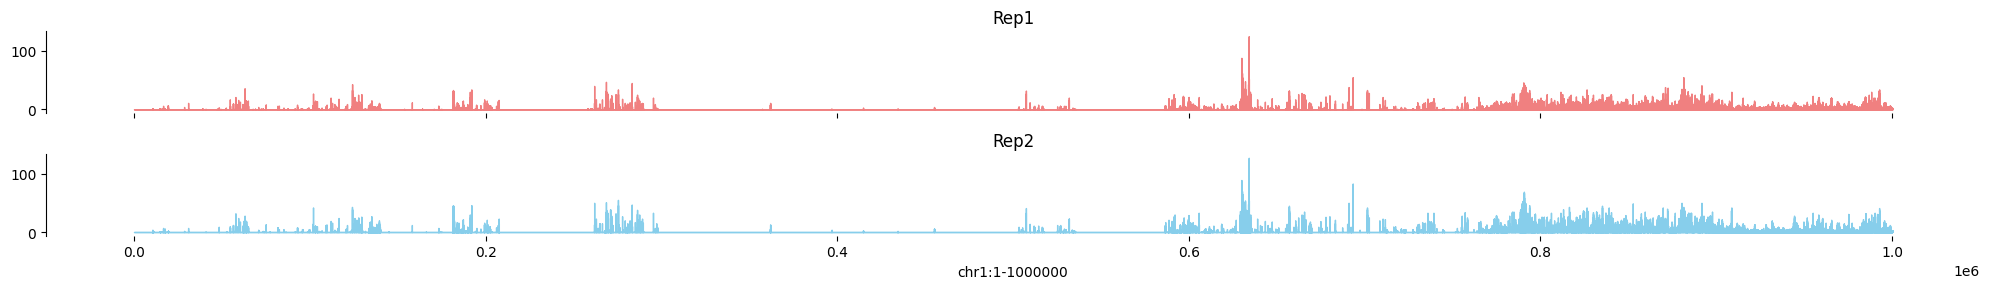

In [74]:
plot_tracks(
    tracks={
        'Rep1': rep1_vals,
        'Rep2': rep2_vals
    },
    interval=interval,
    colors={
        'Rep1': 'lightcoral',
        'Rep2': 'skyblue'
    }
)

In [75]:
# correlation
np.corrcoef(rep1_vals, rep2_vals)

array([[1.        , 0.92478266],
       [0.92478266, 1.        ]])

# CpG methylation state

In [60]:
# Read first 1000 lines
# 1. Reference chromosome or scaffold
# 2. Start position in chromosome
# 3. End position in chromosome
# 4. Name of item
# 5. Score from 0-1000 (capped number of reads)
# 6. Strandedness: plus (+), minus (-), or unknown (.)
# 7. Start of where display should be thick (start codon)
# 8. End of where display should be thick (stop codon)
# 9. Color value (RGB)
# 10. Coverage, or number of reads
# 11. Percentage of reads that show methylation at this position in the genome

# Dont know what 11, 12, 13 are

BED_METHYL_SCHEMA = [
    'chrom', 'chromStart', 'chromEnd', 'name', 'score', 'strand', 'thickStart', 'thickEnd', 'itemRgb', 'coverage', 'methylation', '11', '12', '13'
]
#rep1_bed = pd.read_csv('processed/ENCFF820ATI_HepG2_WGBS_CpG_methylation_state_rep1.bed.gz', sep='\t', header=None, names=BED_METHYL_SCHEMA)
rep2_bed = pd.read_csv('processed/ENCFF690FNR_HepG2_WGBS_CpG_methylation_state_rep2.bed.gz', sep='\t', header=None, names=BED_METHYL_SCHEMA)

In [61]:
#rep1_bed["methylation_coverage"] = round((rep1_bed["methylation"]/100) * rep1_bed["coverage"], 0)
rep2_bed["methylation_coverage"] = round((rep2_bed["methylation"]/100) * rep2_bed["coverage"], 0)

In [62]:
# Remove any 0 coverage rows
#rep1_bed = rep1_bed[rep1_bed["methylation_coverage"] > 0]
rep2_bed = rep2_bed[rep2_bed["methylation_coverage"] > 0]
#print(f"Number of non 0 rows: {len(rep1_bed)}")
print(f"Number of non 0 rows: {len(rep2_bed)}")

Number of non 0 rows: 33618173


In [63]:
# Sort on chrom and chromStart
#rep1_bed = rep1_bed.sort_values(["chrom", "chromStart"])
rep2_bed = rep2_bed.sort_values(["chrom", "chromStart"])

In [64]:
for rep, bed in zip(['rep2'], [rep2_bed]):
    print(f"Writing bigwig for {rep}")
    bw = pyBigWig.open(f'processed/HepG2_WGBS_CpG_methylation_coverage_{rep}.bigWig', 'w')
    bw.addHeader(chrom_sizes, maxZooms=0)
    bw.addEntries(
        list(bed["chrom"].values.astype(str)), 
        list(bed["chromStart"].values), 
        ends=list(bed["chromEnd"].values), 
        values=bed["methylation_coverage"].values.astype("float64")
    )
    bw.close()

Writing bigwig for rep2


In [65]:
rep1_bw_methyl = pyBigWig.open('processed/HepG2_WGBS_CpG_methylation_coverage_rep1.bigWig')
rep2_bw_methyl = pyBigWig.open('processed/HepG2_WGBS_CpG_methylation_coverage_rep2.bigWig')

In [66]:
rep1_methyl_vals = np.nan_to_num(np.array(rep1_bw_methyl.values(chrom, chromStart, chromEnd)))
rep2_methyl_vals = np.nan_to_num(np.array(rep2_bw_methyl.values(chrom, chromStart, chromEnd)))

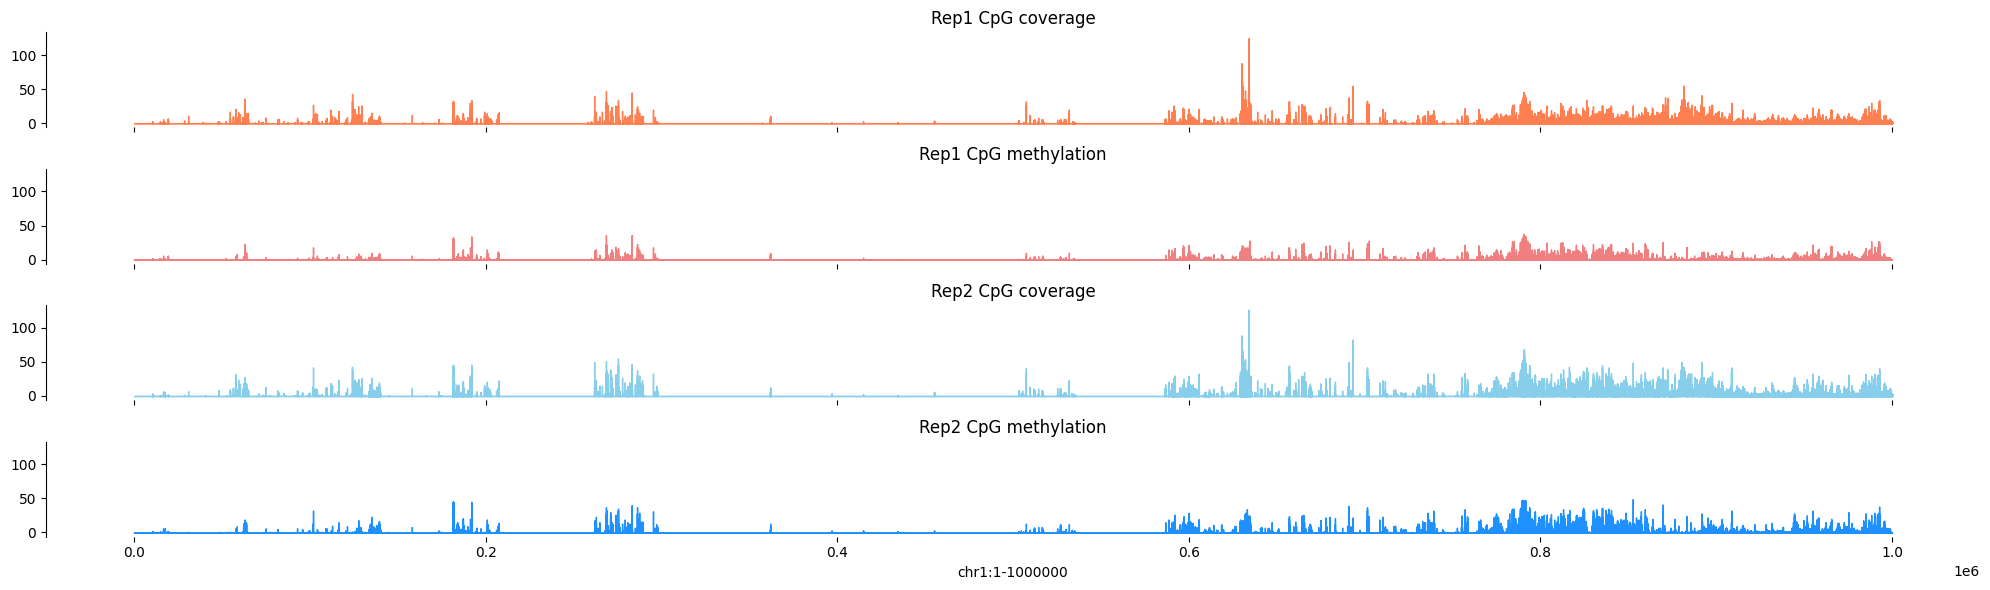

In [67]:
plot_tracks(
    tracks={
        'Rep1 CpG coverage': rep1_vals,
        'Rep1 CpG methylation': rep1_methyl_vals,
        'Rep2 CpG coverage': rep2_vals,
        'Rep2 CpG methylation': rep2_methyl_vals
    },
    interval=interval,
    colors={
        'Rep1 CpG coverage': 'coral',
        'Rep1 CpG methylation': 'lightcoral',
        'Rep2 CpG coverage': 'skyblue',
        'Rep2 CpG methylation': 'dodgerblue'
    },
    sharey=True
)

# SeqData

In [31]:
import seqdata as sd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [51]:
min_cov = 100
min_cpgs = 50

In [2]:
sdata = sd.open_zarr("/cellar/users/aklie/projects/ML4GLand/tutorials/bulk_wgbs_basepair/eugene/prep_dataset/5kb/HepG2_WGBS.minimal.seqdata")
sdata

<xarray.Dataset> Size: 28GB
Dimensions:     (_sequence: 617665, cov_sample: 2, _length: 5000)
Coordinates:
  * _sequence   (_sequence) <U11 27MB 'loci_0' 'loci_1' ... 'loci_617664'
  * cov_sample  (cov_sample) object 16B 'CpG_methylation_coverage_rep1' 'CpG_...
Dimensions without coordinates: _length
Data variables:
    chrom       (_sequence) object 5MB dask.array<chunksize=(77209,), meta=np.ndarray>
    chromEnd    (_sequence) int64 5MB dask.array<chunksize=(77209,), meta=np.ndarray>
    chromStart  (_sequence) int64 5MB dask.array<chunksize=(77209,), meta=np.ndarray>
    cov         (_sequence, cov_sample, _length) float32 25GB dask.array<chunksize=(10000, 1, 5000), meta=np.ndarray>
    fold_0      (_sequence) <U5 12MB dask.array<chunksize=(38605,), meta=np.ndarray>
    fold_1      (_sequence) <U5 12MB dask.array<chunksize=(38605,), meta=np.ndarray>
    fold_2      (_sequence) <U5 12MB dask.array<chunksize=(38605,), meta=np.ndarray>
    fold_3      (_sequence) <U5 12MB dask.array<chunksize=(38605,), meta=np.ndarray>
    fold_4      (_sequence) <U5 12MB dask.array<chunksize=(38605,), meta=np.ndarray>
    seq         (_sequence, _length) |S1 3GB dask.array<chunksize=(10000, 5000), meta=np.ndarray>
    strand      (_sequence) object 5MB dask.array<chunksize=(77209,), meta=np.ndarray>
    type        (_sequence) <U4 10MB dask.array<chunksize=(38605,), meta=np.ndarray>
Attributes:
    length_dim:    _length
    max_jitter:    0
    sequence_dim:  _sequence

In [ ]:
# Total coverage in each 5kb bin
total_coverage = sdata.cov[:, 1, :].sum(dim="_length").values

In [34]:
# Num CpG sites covered (number of non 0 coverage sites)
num_cpg_sites_covered = (sdata.cov[:, 1, :] > 0).sum(dim="_length").values

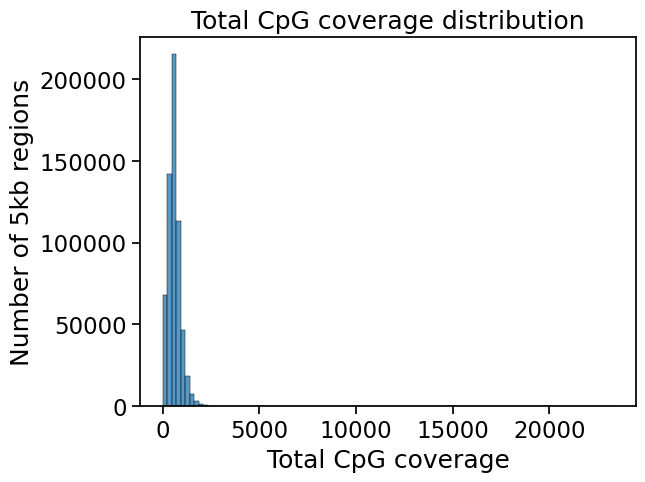

In [35]:
with sns.plotting_context("notebook", font_scale=1.5):
    sns.histplot(total_coverage, bins=100)
    plt.xlabel("Total CpG coverage")
    plt.ylabel("Number of 5kb regions")
    plt.title("Total CpG coverage distribution")

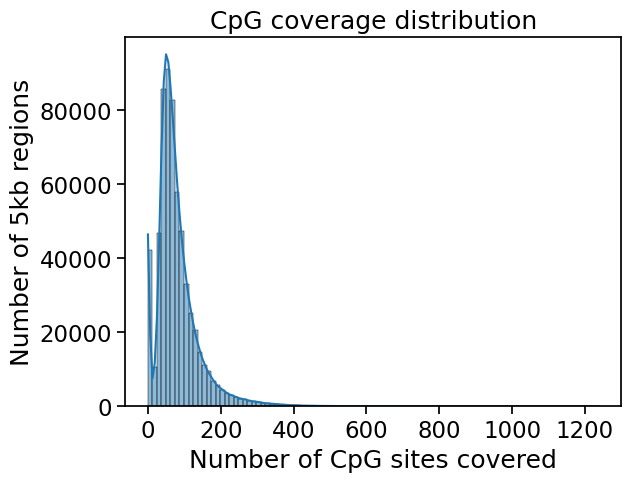

In [36]:
# CpG coverage distribution
with sns.plotting_context("notebook", font_scale=1.5):
    sns.histplot(num_cpg_sites_covered, bins=100, kde=True)
    plt.xlabel("Number of CpG sites covered")
    plt.ylabel("Number of 5kb regions")
    plt.title("CpG coverage distribution")

In [52]:
# How many 5kb regions have at least 30 coverage and 5 CpG sites
good_regions = (total_coverage >= min_cov) & (num_cpg_sites_covered >= min_cpgs)
good_regions.sum()

432359

In [53]:
total_coverage

array([ 0.,  0., 30., ...,  0.,  0.,  0.], dtype=float32)

In [54]:
num_cpg_sites_covered

array([ 0,  0, 16, ...,  0,  0,  0])

In [55]:
good_regions

array([False, False, False, ..., False, False, False])

In [56]:
sdata_filt = sdata.sel(_sequence=good_regions)

In [59]:
sdata_filt

<xarray.Dataset> Size: 20GB
Dimensions:     (_sequence: 432359, cov_sample: 2, _length: 5000)
Coordinates:
  * _sequence   (_sequence) <U11 19MB 'loci_27' 'loci_36' ... 'loci_617596'
  * cov_sample  (cov_sample) object 16B 'CpG_methylation_coverage_rep1' 'CpG_...
Dimensions without coordinates: _length
Data variables:
    chrom       (_sequence) object 3MB dask.array<chunksize=(56540,), meta=np.ndarray>
    chromEnd    (_sequence) int64 3MB dask.array<chunksize=(56540,), meta=np.ndarray>
    chromStart  (_sequence) int64 3MB dask.array<chunksize=(56540,), meta=np.ndarray>
    cov         (_sequence, cov_sample, _length) float32 17GB dask.array<chunksize=(9235, 1, 5000), meta=np.ndarray>
    fold_0      (_sequence) <U5 9MB dask.array<chunksize=(25973,), meta=np.ndarray>
    fold_1      (_sequence) <U5 9MB dask.array<chunksize=(25973,), meta=np.ndarray>
    fold_2      (_sequence) <U5 9MB dask.array<chunksize=(25973,), meta=np.ndarray>
    fold_3      (_sequence) <U5 9MB dask.array<chunksize=(25973,), meta=np.ndarray>
    fold_4      (_sequence) <U5 9MB dask.array<chunksize=(25973,), meta=np.ndarray>
    seq         (_sequence, _length) |S1 2GB dask.array<chunksize=(9235, 5000), meta=np.ndarray>
    strand      (_sequence) object 3MB dask.array<chunksize=(56540,), meta=np.ndarray>
    type        (_sequence) <U4 7MB dask.array<chunksize=(25973,), meta=np.ndarray>
Attributes:
    length_dim:    _length
    max_jitter:    0
    sequence_dim:  _sequence

In [60]:
sdata_filt[['chrom', 'chromStart', 'chromEnd']].to_pandas()

,chrom,chromStart,chromEnd
_sequence,,,
loci_27,chr1,135000,140000
loci_36,chr1,180000,185000
loci_37,chr1,185000,190000
loci_38,chr1,190000,195000
loci_118,chr1,590000,595000
...,...,...,...
loci_617591,chrY,56860000,56865000
loci_617593,chrY,56870000,56875000
loci_617594,chrY,56875000,56880000


In [63]:
ser

NameError: name 'ser' is not defined

In [64]:
sdata_filt[["chrom", "chromStart", "chromEnd"]].to_dataframe()

,chrom,chromStart,chromEnd
_sequence,,,
loci_27,chr1,135000,140000
loci_36,chr1,180000,185000
loci_37,chr1,185000,190000
loci_38,chr1,190000,195000
loci_118,chr1,590000,595000
...,...,...,...
loci_617591,chrY,56860000,56865000
loci_617593,chrY,56870000,56875000
loci_617594,chrY,56875000,56880000


In [66]:
rep1_bw

NameError: name 'rep1_bw' is not defined

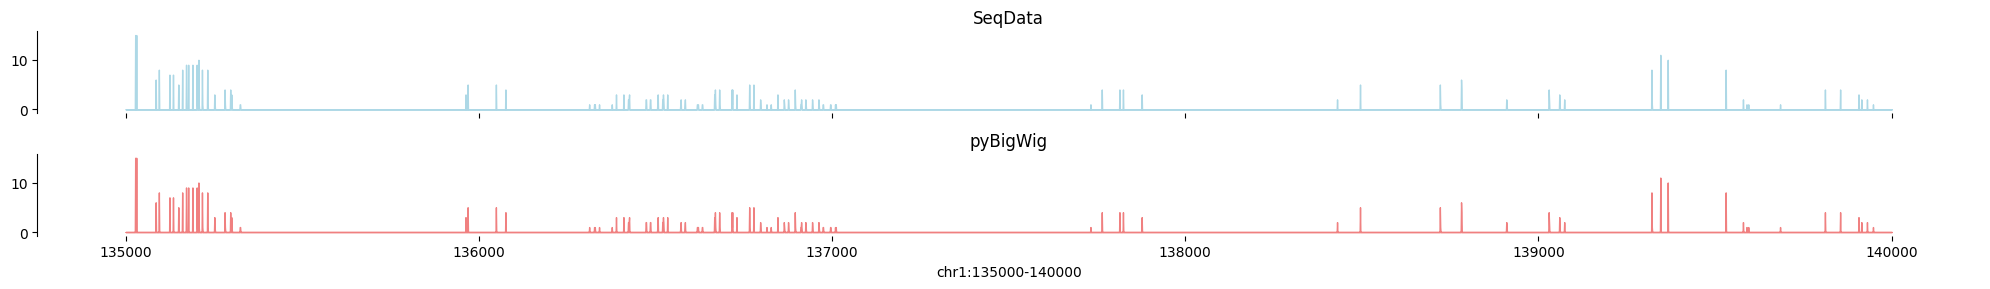

In [76]:
seq_num = 0
ser = sdata_filt[["chrom", "chromStart", "chromEnd"]].to_dataframe().iloc[seq_num]
sdata_vals = sdata_filt["cov"][seq_num, 1, :].values.squeeze()
pybw_vals = np.nan_to_num(np.array(rep1_bw.values(ser["chrom"], ser["chromStart"], ser["chromEnd"])))
chrom = ser["chrom"]
chromStart = ser["chromStart"]
chromEnd = ser["chromEnd"]
interval = dict(chrom=chrom, start=chromStart, end=chromEnd)
tracks = {
    "SeqData": sdata_vals,
    "pyBigWig": pybw_vals
}
colors = {
    "SeqData": "lightblue",
    "pyBigWig": "lightcoral"
}

# Plot tracks
plot_tracks(
    tracks=tracks,
    interval=interval,
    colors=colors
)

# DONE!

---

# Sanity checks

In [ ]:
rep1_bed["bw_cov"] = rep1_vals[rep1_bed.chromStart.values - 1]

In [ ]:
import seaborn as sns

<Axes: xlabel='coverage', ylabel='bw_cov'>

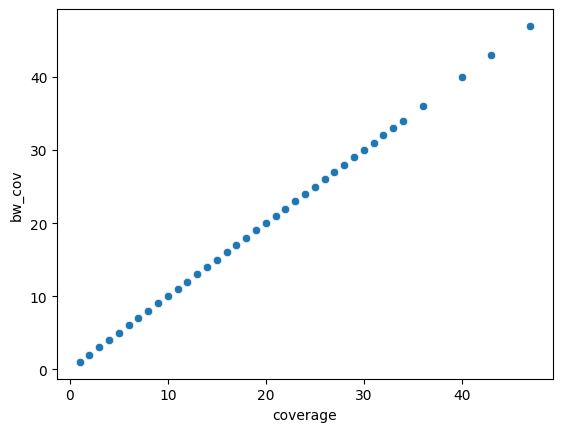

In [ ]:
sns.scatterplot(x='coverage', y='bw_cov', data=rep1_bed)

In [ ]:
12*0.58

6.959999999999999